Importing the Dependencies


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data (1) (1) (1).csv to data (1) (1) (1).csv


FileNotFoundError: [Errno 2] No such file or directory: '/content/dataset(1).csv'

In [ ]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import NullFormatter
import pandas as pd
import numpy as np
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn import preprocessing
%matplotlib inline

Data Collection and Processing

In [ ]:
# loading the dataset to pandas DataFrame
df = pd.read_csv('/content/data.csv')


In [ ]:
 # Display first 10 rows
print(df.head())

   Unnamed: 0.1  Unnamed: 0 loan_status  Principal  terms effective_date  \
0             0           0     PAIDOFF       1000     30       9/8/2016   
1             2           2     PAIDOFF       1000     30       9/8/2016   
2             3           3     PAIDOFF       1000     15       9/8/2016   
3             4           4     PAIDOFF       1000     30       9/9/2016   
4             6           6     PAIDOFF       1000     30       9/9/2016   

    due_date  age             education  Gender  
0  10/7/2016   45  High School or Below    male  
1  10/7/2016   33              Bechalor  female  
2  9/22/2016   27               college    male  
3  10/8/2016   28               college  female  
4  10/8/2016   29               college    male  


In [ ]:
# number of rows and columns
df.shape

(346, 10)

Covert to data time object

In [ ]:
print(df.columns)

Index(['Unnamed: 0.1', 'Unnamed: 0', 'loan_status', 'Principal', 'terms',
       'effective_date', 'due_date', 'age', 'education', 'Gender'],
      dtype='object')


In [ ]:
df['due_date'] = pd.to_datetime(df['due_date'])
df['effective_date'] = pd.to_datetime(df['effective_date'])
df.head()

,Unnamed: 0.1,Unnamed: 0,loan_status,Principal,terms,effective_date,due_date,age,education,Gender
0,0,0,PAIDOFF,1000,30,2016-09-08,2016-10-07,45,High School or Below,male
1,2,2,PAIDOFF,1000,30,2016-09-08,2016-10-07,33,Bechalor,female
2,3,3,PAIDOFF,1000,15,2016-09-08,2016-09-22,27,college,male
3,4,4,PAIDOFF,1000,30,2016-09-09,2016-10-08,28,college,female
4,6,6,PAIDOFF,1000,30,2016-09-09,2016-10-08,29,college,male


Data Visualization and Preprocessing

In [ ]:
df['loan_status'].value_counts()

,count
loan_status,
PAIDOFF,260
COLLECTION,86


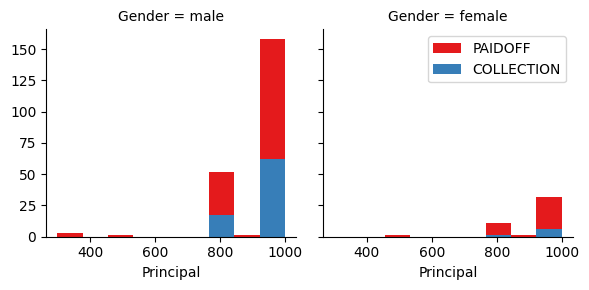

In [ ]:
bins = np.linspace(df.Principal.min(), df.Principal.max(), 10)
g = sns.FacetGrid(df, col="Gender", hue="loan_status", palette="Set1", col_wrap=2)
g.map(plt.hist, 'Principal', bins=bins, ec="k")

g.axes[-1].legend()
plt.show()



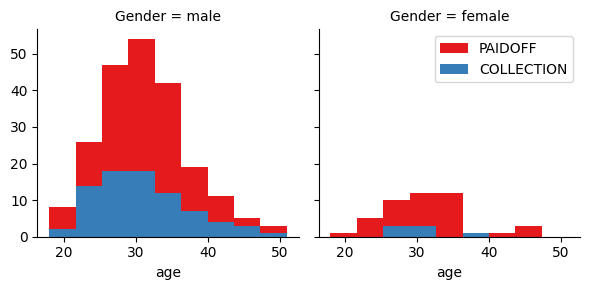

In [ ]:
bins = np.linspace(df.age.min(), df.age.max(), 10)
g = sns.FacetGrid(df, col="Gender", hue="loan_status", palette="Set1", col_wrap=2)
g.map(plt.hist, 'age', bins=bins, ec="k")

g.axes[-1].legend()
plt.show()

Pre-processing:Features Selection/extraction

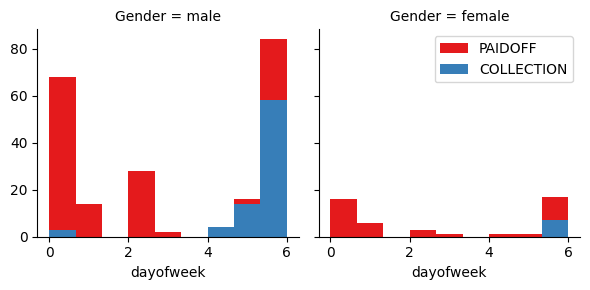

In [ ]:
df['dayofweek'] = df['effective_date'].dt.dayofweek
bins = np.linspace(df.dayofweek.min(), df.dayofweek.max(), 10)
g = sns.FacetGrid(df, col="Gender", hue="loan_status", palette="Set1", col_wrap=2)
g.map(plt.hist, 'dayofweek', bins=bins, ec="k")
g.axes[-1].legend()
plt.show()

In [ ]:
df['weekend'] = df['dayofweek'].apply(lambda x: 1 if (x>3)  else 0)
df.head()

,Unnamed: 0.1,Unnamed: 0,loan_status,Principal,terms,effective_date,due_date,age,education,Gender,dayofweek,weekend
0,0,0,PAIDOFF,1000,30,2016-09-08,2016-10-07,45,High School or Below,male,3,0
1,2,2,PAIDOFF,1000,30,2016-09-08,2016-10-07,33,Bechalor,female,3,0
2,3,3,PAIDOFF,1000,15,2016-09-08,2016-09-22,27,college,male,3,0
3,4,4,PAIDOFF,1000,30,2016-09-09,2016-10-08,28,college,female,4,1
4,6,6,PAIDOFF,1000,30,2016-09-09,2016-10-08,29,college,male,4,1


 Replace values in loan_status column

Convert Categorical features to numerical values

In [ ]:
print(df.columns)

Index(['Unnamed: 0.1', 'Unnamed: 0', 'loan_status', 'Principal', 'terms',
       'effective_date', 'due_date', 'age', 'education', 'Gender', 'dayofweek',
       'weekend'],
      dtype='object')


In [ ]:
df.groupby(['Gender'])['loan_status'].value_counts(normalize=True)

Gender  loan_status
female  PAIDOFF        0.865385
        COLLECTION     0.134615
male    PAIDOFF        0.731293
        COLLECTION     0.268707
Name: proportion, dtype: float64

In [ ]:
df['Gender'].replace(to_replace=['male','female'], value=[0,1],inplace=True)
df.head()

<ipython-input-148-16d8d3bfffa5>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].replace(to_replace=['male','female'], value=[0,1],inplace=True)
<ipython-input-148-16d8d3bfffa5>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender'].replace(to_replace=['male','female'], value=[0

,Unnamed: 0.1,Unnamed: 0,loan_status,Principal,terms,effective_date,due_date,age,education,Gender,dayofweek,weekend
0,0,0,PAIDOFF,1000,30,2016-09-08,2016-10-07,45,High School or Below,0,3,0
1,2,2,PAIDOFF,1000,30,2016-09-08,2016-10-07,33,Bechalor,1,3,0
2,3,3,PAIDOFF,1000,15,2016-09-08,2016-09-22,27,college,0,3,0
3,4,4,PAIDOFF,1000,30,2016-09-09,2016-10-08,28,college,1,4,1
4,6,6,PAIDOFF,1000,30,2016-09-09,2016-10-08,29,college,0,4,1


One Hot Encoding

In [ ]:
print(df.columns)

Index(['Unnamed: 0.1', 'Unnamed: 0', 'loan_status', 'Principal', 'terms',
       'effective_date', 'due_date', 'age', 'education', 'Gender', 'dayofweek',
       'weekend'],
      dtype='object')


In [ ]:
df.columns = df.columns.str.lower()
df.groupby(['education'])['loan_status'].value_counts(normalize=True)


education             loan_status
Bechalor              PAIDOFF        0.750000
                      COLLECTION     0.250000
High School or Below  PAIDOFF        0.741722
                      COLLECTION     0.258278
Master or Above       COLLECTION     0.500000
                      PAIDOFF        0.500000
college               PAIDOFF        0.765101
                      COLLECTION     0.234899
Name: proportion, dtype: float64

In [ ]:
print(df.columns)

Index(['unnamed: 0.1', 'unnamed: 0', 'loan_status', 'principal', 'terms',
       'effective_date', 'due_date', 'age', 'education', 'gender', 'dayofweek',
       'weekend'],
      dtype='object')


In [ ]:
df[['principal','terms','age','gender','education']].head()

,principal,terms,age,gender,education
0,1000,30,45,0,High School or Below
1,1000,30,33,1,Bechalor
2,1000,15,27,0,college
3,1000,30,28,1,college
4,1000,30,29,0,college


Optional: Check the value counts to confirm the replacement

In [ ]:
Feature = df[['principal','terms','age','gender','weekend']]
Feature = pd.concat([Feature,pd.get_dummies(df['education'])], axis=1)
Feature.drop(['Master or Above'], axis = 1,inplace=True)
Feature.head()

,principal,terms,age,gender,weekend,Bechalor,High School or Below,college
0,1000,30,45,0,0,False,True,False
1,1000,30,33,1,0,True,False,False
2,1000,15,27,0,0,False,False,True
3,1000,30,28,1,1,False,False,True
4,1000,30,29,0,1,False,False,True


Feature selection

In [ ]:
X = Feature
X[0:5]

,principal,terms,age,gender,weekend,Bechalor,High School or Below,college
0,1000,30,45,0,0,False,True,False
1,1000,30,33,1,0,True,False,False
2,1000,15,27,0,0,False,False,True
3,1000,30,28,1,1,False,False,True
4,1000,30,29,0,1,False,False,True


Normalize Data

In [ ]:
X= preprocessing.StandardScaler().fit(X).transform(X)
X[0:5]

array([[ 0.51578458,  0.92071769,  2.33152555, -0.42056004, -1.20577805,
        -0.38170062,  1.13639374, -0.86968108],
       [ 0.51578458,  0.92071769,  0.34170148,  2.37778177, -1.20577805,
         2.61985426, -0.87997669, -0.86968108],
       [ 0.51578458, -0.95911111, -0.65321055, -0.42056004, -1.20577805,
        -0.38170062, -0.87997669,  1.14984679],
       [ 0.51578458,  0.92071769, -0.48739188,  2.37778177,  0.82934003,
        -0.38170062, -0.87997669,  1.14984679],
       [ 0.51578458,  0.92071769, -0.3215732 , -0.42056004,  0.82934003,
        -0.38170062, -0.87997669,  1.14984679]])

In [ ]:
y = df['loan_status']

Model Training

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
import matplotlib.pyplot as plt

In [ ]:
from sklearn.model_selection import train_test_split
X_trainset, X_testset, y_trainset, y_testset = train_test_split( X, y, test_size=0.2, random_state=4)

In [ ]:
k_acc = []

for k in range(1, 20):
    neigh = KNeighborsClassifier(n_neighbors=k).fit(X_trainset, y_trainset)
    yhat = neigh.predict(X_testset)

    acc = metrics.accuracy_score(y_testset, yhat)
    print(f"Test set Accuracy: {acc:.4f} - k = {k}")
    k_acc.append(acc)


Test set Accuracy: 0.6429 - k = 1
Test set Accuracy: 0.5857 - k = 2
Test set Accuracy: 0.7429 - k = 3
Test set Accuracy: 0.7000 - k = 4
Test set Accuracy: 0.7429 - k = 5
Test set Accuracy: 0.7143 - k = 6
Test set Accuracy: 0.8000 - k = 7
Test set Accuracy: 0.7571 - k = 8
Test set Accuracy: 0.7429 - k = 9
Test set Accuracy: 0.6857 - k = 10
Test set Accuracy: 0.7143 - k = 11
Test set Accuracy: 0.7143 - k = 12
Test set Accuracy: 0.6857 - k = 13
Test set Accuracy: 0.7000 - k = 14
Test set Accuracy: 0.6857 - k = 15
Test set Accuracy: 0.7286 - k = 16
Test set Accuracy: 0.7143 - k = 17
Test set Accuracy: 0.7143 - k = 18
Test set Accuracy: 0.7143 - k = 19


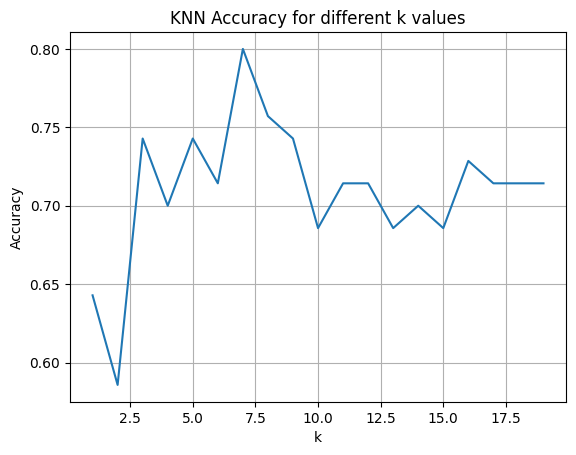

In [ ]:
plt.plot(range(1, 20), k_acc)
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy for different k values')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import f1_score
from sklearn.metrics import log_loss

In [ ]:
neigh = KNeighborsClassifier(n_neighbors = 7).fit(X_trainset,y_trainset)
knn_pred=neigh.predict(X_testset)
print("F1-SCORE:: ",f1_score( y_testset, knn_pred, average='weighted'))
print("Logloss score: ", log_loss(y_testset,neigh.predict_proba(X_testset)))

F1-SCORE::  0.8
Logloss score:  0.46308514610813184


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
X_trainset, X_testset, y_trainset, y_testset = train_test_split(X, y, test_size=0.2, random_state=4)

In [ ]:
print("X-trainset-shape:: ", X_trainset.shape)
print("Y-trainset-shape:: ", y_trainset.shape)
loanTree = DecisionTreeClassifier(criterion="entropy",max_depth=6)
loanTree

X-trainset-shape::  (276, 8)
Y-trainset-shape::  (276,)


DecisionTreeClassifier(criterion='entropy', max_depth=6)

In [ ]:
loanTree.fit(X_trainset,y_trainset)

DecisionTreeClassifier(criterion='entropy', max_depth=6)

In [ ]:
predTree = loanTree.predict(X_testset)
print ("PREDICTED -- >", predTree [0:10])
print ("ACTUAL --> ", y_testset [0:10])

PREDICTED -- > ['PAIDOFF' 'PAIDOFF' 'PAIDOFF' 'PAIDOFF' 'PAIDOFF' 'PAIDOFF' 'COLLECTION'
 'COLLECTION' 'PAIDOFF' 'PAIDOFF']
ACTUAL -->  63        PAIDOFF
34        PAIDOFF
186       PAIDOFF
146       PAIDOFF
130       PAIDOFF
178       PAIDOFF
334    COLLECTION
14        PAIDOFF
166       PAIDOFF
101       PAIDOFF
Name: loan_status, dtype: object


In [ ]:
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

In [ ]:
print("DecisionTrees's Accuracy: ", metrics.accuracy_score(y_testset, predTree))

DecisionTrees's Accuracy:  0.7714285714285715


In [ ]:
print("F1_score: ",f1_score(y_testset, predTree,average='weighted'))

F1_score:  0.70647931303669


In [ ]:
from sklearn import svm
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
X_trainset, X_testset, y_trainset, y_testset = train_test_split( X, y, test_size=0.2, random_state=4)

In [ ]:
clf = svm.SVC(kernel='linear')
clf.fit(X_trainset, y_trainset)
yhat = clf.predict(X_testset)

In [ ]:
print("SVM linear kernel: accuracy ", metrics.accuracy_score(y_testset, yhat), " \n F1: ", f1_score(y_testset, yhat, average='weighted'),  )

SVM linear kernel: accuracy  0.7857142857142857  
 F1:  0.6914285714285714


In [ ]:
clf = svm.SVC(kernel='poly')
clf.fit(X_trainset, y_trainset)
yhat = clf.predict(X_testset)

In [ ]:
print("SVM polynomial kernel: accuracy ", metrics.accuracy_score(y_testset, yhat), " \nF1: ", f1_score(y_testset, yhat, average='weighted'))

SVM polynomial kernel: accuracy  0.7714285714285715  
F1:  0.70647931303669


In [ ]:
clf = svm.SVC(kernel='rbf')
clf.fit(X_trainset, y_trainset)
yhat = clf.predict(X_testset)

In [ ]:
print("SVM rbf kernel: accuracy ", metrics.accuracy_score(y_testset, yhat), " \nF1: ", f1_score(y_testset, yhat, average='weighted'))

SVM rbf kernel: accuracy  0.7428571428571429  
F1:  0.7275882012724116


In [ ]:
clf = svm.SVC(kernel='sigmoid')
clf.fit(X_trainset, y_trainset)
yhat = clf.predict(X_testset)

In [ ]:
print("SVM sigmoid kernel: accuracy ", metrics.accuracy_score(y_testset, yhat), " \nF1: ", f1_score(y_testset, yhat, average='weighted'))

SVM sigmoid kernel: accuracy  0.7428571428571429  
F1:  0.6892857142857143


In [ ]:
from sklearn.linear_model import LogisticRegression


In [ ]:
LR = LogisticRegression(C=0.01, solver='newton-cg').fit(X_trainset,y_trainset)
yhat_lr = LR.predict(X_testset)

In [ ]:
print("LR newton-cg solver: accuracy ", metrics.accuracy_score(y_testset, yhat_lr), " \nF1: ", f1_score(y_testset, yhat_lr, average='weighted'))

LR newton-cg solver: accuracy  0.7857142857142857  
F1:  0.6914285714285714


In [ ]:
print("Logloss score: ", log_loss(y_testset,LR.predict_proba(X_testset)))

Logloss score:  0.49201257125190695


In [ ]:
LR = LogisticRegression(C=0.01, solver='liblinear').fit(X_trainset,y_trainset)
yhat_lr = LR.predict(X_testset)


In [ ]:
print("LR liblinear solver: accuracy ", metrics.accuracy_score(y_testset, yhat_lr), " \nF1: ", f1_score(y_testset, yhat_lr, average='weighted'))

LR liblinear solver: accuracy  0.6857142857142857  
F1:  0.6670522459996143


In [ ]:
print("Logloss score: ", log_loss(y_testset,LR.predict_proba(X_testset)))

Logloss score:  0.5772287609479654


In [ ]:
LR = LogisticRegression(C=0.01, solver='saga').fit(X_trainset,y_trainset)
yhat_lr = LR.predict(X_testset)

In [ ]:
print("LR saga solver: accuracy ", metrics.accuracy_score(y_testset, yhat_lr), " \nF1: ", f1_score(y_testset, yhat_lr, average='weighted'))

LR saga solver: accuracy  0.7857142857142857  
F1:  0.6914285714285714


In [ ]:
print("Logloss score: ", log_loss(y_testset,LR.predict_proba(X_testset)))

Logloss score:  0.4920183442376928


In [ ]:
table = [["KNN",0.7765,0.4671],["Decision Tree",0.6466,'NA'],
...          ["SVM",0.6914,'NA'],["LogisticRegression",0.6914,0.4920]]

In [ ]:
from tabulate import tabulate
from IPython.display import HTML
HTML(tabulate(table, headers= ['Algorithm', 'F1-score','LogLoss'], tablefmt='html'))

Algorithm,F1-score,LogLoss
KNN,0.7765,0.4671
Decision Tree,0.6466,NA
SVM,0.6914,NA
LogisticRegression,0.6914,0.492


In [ ]:
!pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 111.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 105.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.3 MB/s eta 0:00:00


In [ ]:
!pip install joblib

In [ ]:
!pip install streamlit pyngrok

In [ ]:
!pip install pyngrok

In [ ]:
!wget -q -nc https://bin.equinox.io/c/4VmDzA7iaHb/ngrok-stable-linux-amd64.zip
!unzip -o ngrok-stable-linux-amd64.zip

Archive:  ngrok-stable-linux-amd64.zip
  inflating: ngrok                   


In [ ]:
!./ngrok authtoken 2xOvwc6Ll7lb3PTEntOvfmP8tXu_7yqmeQzPw3FroK2UEoUL9


Authtoken saved to configuration file: /root/.ngrok2/ngrok.yml


In [ ]:
get_ipython().system_raw('./ngrok http 8501 &')


In [ ]:
!wget -q -o - ipv4.icanhazip.com

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib

In [ ]:
df = pd.read_csv("/content/data.csv")

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_gender = LabelEncoder()
le_education = LabelEncoder()


In [ ]:
le_gender = LabelEncoder()
le_education = LabelEncoder()

In [ ]:
df['Gender_encoded'] = le_gender.fit_transform(df['Gender'])
df['education_encoded'] = le_education.fit_transform(df['education'])

In [ ]:
X = df[["Principal", "terms", "age", "education_encoded", "Gender_encoded"]]
y = df["loan_status"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.6714285714285714
Classification Report:
               precision    recall  f1-score   support

  COLLECTION       0.10      0.07      0.08        15
     PAIDOFF       0.77      0.84      0.80        55

    accuracy                           0.67        70
   macro avg       0.43      0.45      0.44        70
weighted avg       0.62      0.67      0.65        70



In [ ]:
y_pred = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6714285714285714
Classification Report:
               precision    recall  f1-score   support

  COLLECTION       0.10      0.07      0.08        15
     PAIDOFF       0.77      0.84      0.80        55

    accuracy                           0.67        70
   macro avg       0.43      0.45      0.44        70
weighted avg       0.62      0.67      0.65        70



In [ ]:
import joblib

joblib.dump(knn, "knn_model.pkl")


['knn_model.pkl']

In [ ]:
%%writefile app.py
import streamlit as st

st.title("LoanRisk Predictor")
st.write("Enter loan details to predict status:")

# Example input fields
principal = st.number_input("Principal")
terms = st.selectbox("Terms", [7, 14, 30])
age = st.slider("Age", 18, 70)
education = st.selectbox("Education", ['High School', 'College', 'Bechalor', 'Master', 'Doctorate'])
gender = st.selectbox("Gender", ['male', 'female'])

# Just dummy output
if st.button("Predict"):
    st.success("Predicted: PAIDOFF")  # just for example


Writing app.py


In [ ]:
!streamlit run app.py &>/content/log.txt &


In [ ]:
!wget -q -nc https://bin.equinox.io/c/4VmDzA7iaHb/ngrok-stable-linux-amd64.zip
!unzip -o ngrok-stable-linux-amd64.zip




Archive:  ngrok-stable-linux-amd64.zip
  inflating: ngrok                   


In [ ]:
!./ngrok authtoken 2xOvwc6Ll7lb3PTEntOvfmP8tXu_7yqmeQzPw3FroK2UEoUL9


Authtoken saved to configuration file: /root/.ngrok2/ngrok.yml


In [ ]:
!nohup streamlit run app.py --server.port 8501 &


nohup: appending output to 'nohup.out'


In [ ]:
get_ipython().system_raw('./ngrok http 8501 &')

In [ ]:
%%writefile app.py
import streamlit as st

st.title("LoanRisk Predictor")
st.write("✅ Your Streamlit app is running inside Google Colab!")


Overwriting app.py


In [ ]:
!nohup streamlit run app.py --server.port 8501 &


nohup: appending output to 'nohup.out'


In [ ]:
%%writefile app.py
import streamlit as st
import joblib

model = joblib.load("knn_model.pkl")

st.title("LoanRisk Predictor")
st.write("Enter the details below to predict loan status.")

age = st.number_input("Age", min_value=18, max_value=100)
principal = st.number_input("Loan Amount (Principal)", min_value=100)
terms = st.number_input("Loan Terms (in days)", min_value=7)
education = st.selectbox("Education Level", ["High School", "college", "Bechalor", "Master or Above"])
gender = st.selectbox("Gender", ["male", "female"])

gender_num = 1 if gender == "male" else 0
edu_map = {"High School": 0, "college": 1, "Bechalor": 2, "Master or Above": 3}
education_num = edu_map[education]

input_data = [[principal, terms, age, education_num, gender_num]]

if st.button("Predict"):
    prediction = model.predict(input_data)
    st.subheader("🎯 Prediction: {}".format(prediction[0]))


Overwriting app.py


In [ ]:
model = joblib.load("knn_model.pkl")

In [ ]:
import streamlit as st

In [ ]:
st.write('# LoanRisk Predictor')

2025-06-05 04:43:26.755 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-05 04:43:26.836 
  command:

    streamlit run /usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-06-05 04:43:26.837 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [ ]:
principal = st.number_input('Loan Amount (Principal)', min_value=100, max_value=10000, step=100)
terms = st.selectbox('Loan Term (days)', [15, 30])
age = st.number_input('Borrower Age', min_value=18, max_value=100)
education = st.selectbox('Education Level', ['High School or Below', 'college', 'Bechalor', 'Master or Above'])
gender = st.selectbox('Gender', ['male', 'female'])

2025-06-05 04:43:29.439 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-05 04:43:29.440 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-05 04:43:29.441 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-05 04:43:29.442 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-05 04:43:29.443 Session state does not function when running a script without `streamlit run`
2025-06-05 04:43:29.444 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-05 04:43:29.444 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-05 04:43:29.445 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-05 04:43

In [ ]:
if st.button('Predict Loan Status'):
    prediction = model.predict(input_data)[0]
    st.write('### Loan Status:', prediction)

2025-06-05 04:43:32.887 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-05 04:43:32.888 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-05 04:43:32.889 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-05 04:43:32.890 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-05 04:43:32.891 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [ ]:
from pyngrok import ngrok
import os

In [ ]:
ngrok.kill()

In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("2xOvwc6Ll7lb3PTEntOvfmP8tXu_7yqmeQzPw3FroK2UEoUL9")

In [ ]:
public_url = ngrok.connect("http://localhost:8501")

In [ ]:
print(f"Public URL: {public_url}")

Public URL: NgrokTunnel: "https://11ce-34-86-203-85.ngrok-free.app" -> "http://localhost:8501"


In [ ]:
!streamlit run app.py &> /dev/null &

In [ ]:
print("Streamlit app is live at: https://23af-35-236-207-5.ngrok-free.app")

Streamlit app is live at: https://23af-35-236-207-5.ngrok-free.app


In [ ]:
from pyngrok import ngrok

from pyngrok import ngrok

ngrok.set_auth_token("2xOvwc6Ll7lb3PTEntOvfmP8tXu_7yqmeQzPw3FroK2UEoUL9")
public_url = ngrok.connect("http://localhost:8501")
print(f"Streamlit app is live at: {public_url}")

Streamlit app is live at: NgrokTunnel: "https://9b49-34-86-203-85.ngrok-free.app" -> "http://localhost:8501"
